# Classical Machine Learning vs. Neural Network from Scratch: A Comparative Study on Chronic Kidney Disease Prediction

**Author:** [Your Name]
**Course:** [Course Name]
**Date:** [Date]
**Dataset:** Soundarapandian & Rubini (2015), UCI Machine Learning Repository

**Abstract.** This study compares classical machine learning models (logistic regression, random forest) with a three-layer feedforward neural network built from scratch in NumPy for binary CKD classification. All models are evaluated on accuracy, precision, recall, and F1-score using the UCI Chronic Kidney Disease dataset (Soundarapandian & Rubini, 2015). Results show that ensemble methods and well-tuned neural networks both achieve strong performance, while logistic regression provides a competitive linear baseline.

## 1. Library Imports and Environment Configuration

The cell below loads all required libraries: NumPy and Pandas for data handling, Matplotlib and Seaborn for visualisation, scikit-learn for classical ML models and evaluation metrics (Pedregosa et al., 2011), and `ucimlrepo` for dataset access. No deep learning framework is used — the neural network in Section 5 is built entirely in NumPy.

In [1]:
!pip install ucimlrepo -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_curve, auc)
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

# Plot styling
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

# Global dictionary to accumulate results from all models
all_results = {}

print("All libraries imported successfully.")

All libraries imported successfully.


## 2. Dataset Selection and Justification

Chronic kidney disease affects roughly 9.1% of the global adult population and caused an estimated 1.2 million deaths in 2017 (Bikbov et al., 2020). Because CKD is largely asymptomatic until late stages, early detection using routine clinical measurements is clinically valuable. The dataset used here was collected at Apollo Hospitals, India, and contributed to the UCI Machine Learning Repository by Soundarapandian and Rubini (2015). It contains 400 patient records with 24 features spanning demographics (age, blood pressure), urinalysis (specific gravity, albumin, red blood cells), blood chemistry (haemoglobin, serum creatinine, blood glucose, sodium, potassium), and comorbidity flags (hypertension, diabetes, coronary artery disease). The binary target indicates CKD presence or absence.

This dataset suits our objectives for several reasons: it poses a binary classification problem applicable to both linear and non-linear models; its 24 clinically interpretable features allow domain-grounded analysis; the moderate size (400 × 24) is tractable for a NumPy-only neural network; substantial missing values require principled imputation; and the mild class imbalance (~62.5% CKD, ~37.5% not-CKD) motivates evaluation beyond accuracy alone.

For preprocessing, we apply median imputation to continuous features for robustness to outliers (Little & Rubin, 2002), mode imputation for categoricals, one-hot encoding with `drop_first=True` to avoid multicollinearity (Bishop, 2006, p. 296), and `StandardScaler` normalisation for gradient-based methods. We report accuracy, precision, recall, and $F_1$-score throughout, since precision penalises false alarms while recall penalises missed diagnoses — both clinically important (van Rijsbergen, 1979).

## 3. Data Loading and Preprocessing

### 3.1 Data Loading

The dataset is fetched programmatically via the `ucimlrepo` package using its repository identifier (ID 336). The cell below loads the data and displays its shape, column types, and missingness profile.

In [2]:
# Load the Chronic Kidney Disease dataset from UCI ML Repository
ckd = fetch_ucirepo(id=336)
X = ckd.data.features
y = ckd.data.targets

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape:  {y.shape}")
print(f"\nTarget value counts:")
target_series = y.iloc[:, 0].astype(str).str.strip()
print(target_series.value_counts())

print("\n" + "=" * 60)
print("FIRST 5 ROWS OF FEATURES")
print("=" * 60)
display(X.head())

print("\n" + "=" * 60)
print("COLUMN DATA TYPES")
print("=" * 60)
print(X.dtypes)

print("\n" + "=" * 60)
print("MISSING VALUES PER COLUMN")
print("=" * 60)
missing = X.isnull().sum()
missing_pct = (X.isnull().sum() / len(X) * 100).round(1)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(
    'Missing Count', ascending=False)
display(missing_df)
print(f"\nTotal missing cells: {X.isnull().sum().sum()} "
      f"out of {X.shape[0] * X.shape[1]} "
      f"({X.isnull().sum().sum() / (X.shape[0] * X.shape[1]) * 100:.1f}%)")

DATASET OVERVIEW
Feature matrix shape: (400, 24)
Target vector shape:  (400, 1)

Target value counts:
class
ckd       250
notckd    150
Name: count, dtype: int64

FIRST 5 ROWS OF FEATURES


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,hemo,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,15.4,44.0,7800.0,5.2,yes,yes,no,good,no,no
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,11.3,38.0,6000.0,NaN,no,no,no,good,no,no
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,9.6,31.0,7500.0,NaN,no,yes,no,poor,no,yes
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,11.2,32.0,6700.0,3.9,yes,no,no,poor,yes,yes
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,11.6,35.0,7300.0,4.6,no,no,no,good,no,no



COLUMN DATA TYPES
age      float64
bp       float64
sg       float64
al       float64
su       float64
rbc       object
pc        object
pcc       object
ba        object
bgr      float64
bu       float64
sc       float64
sod      float64
pot      float64
hemo     float64
pcv      float64
wbcc     float64
rbcc     float64
htn       object
dm        object
cad       object
appet     object
pe        object
ane       object
dtype: object

MISSING VALUES PER COLUMN


,Missing Count,Missing %
rbc,152,38.0
rbcc,131,32.8
wbcc,106,26.5
pot,88,22.0
sod,87,21.8
pcv,71,17.8
pc,65,16.2
hemo,52,13.0
su,49,12.2
sg,47,11.8



Total missing cells: 1012 out of 9600 (10.5%)


### 3.2 Exploratory Data Analysis

Before preprocessing, we examine the class distribution, feature distributions for four key clinical variables, inter-feature correlations, and the pattern of missingness across the dataset.

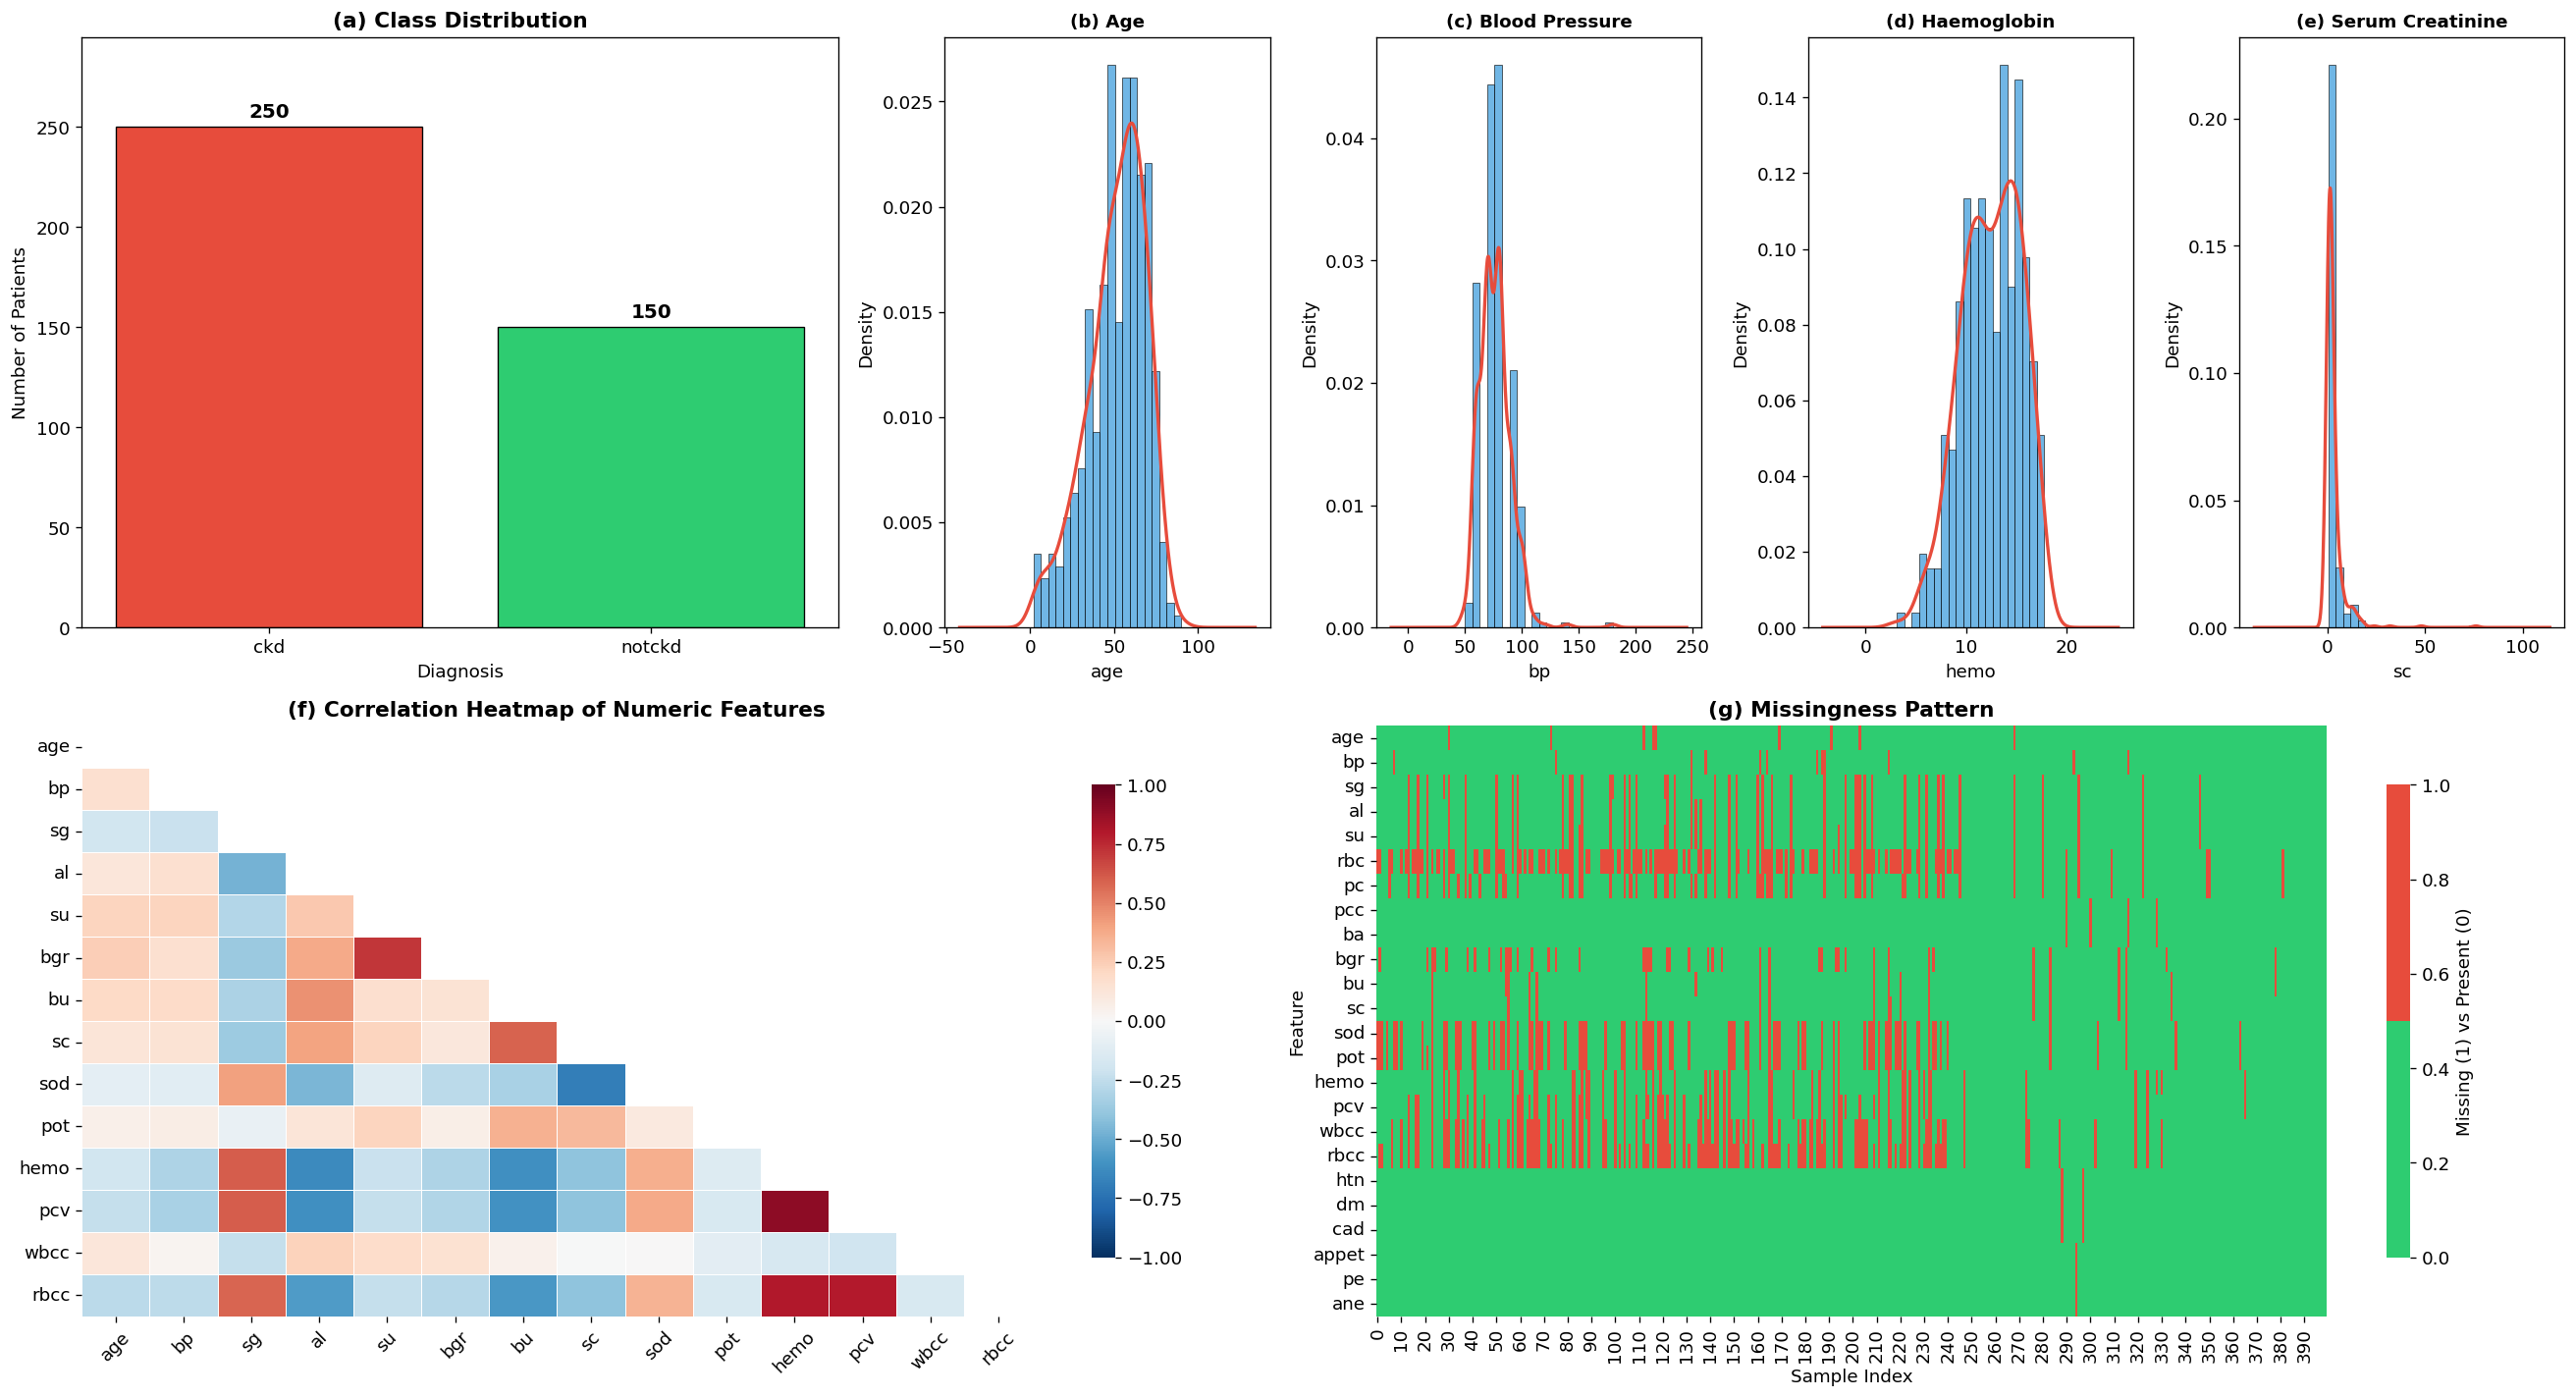

In [3]:
# Prepare target series for EDA
y_temp = y.iloc[:, 0].astype(str).str.strip()

# Identify numeric columns
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

fig = plt.figure(figsize=(22, 12))

# --- Panel 1: Class distribution (row 0, cols 0-1) ---
ax_class = plt.subplot2grid((2, 6), (0, 0), colspan=2)
class_counts = y_temp.value_counts()
bars = ax_class.bar(class_counts.index.astype(str), class_counts.values,
                    color=['#e74c3c', '#2ecc71'], edgecolor='black', linewidth=0.8)
for bar_rect, count in zip(bars, class_counts.values):
    ax_class.text(bar_rect.get_x() + bar_rect.get_width() / 2., bar_rect.get_height() + 3,
                  str(count), ha='center', va='bottom', fontweight='bold', fontsize=12)
ax_class.set_title('(a) Class Distribution', fontweight='bold')
ax_class.set_xlabel('Diagnosis')
ax_class.set_ylabel('Number of Patients')
ax_class.set_ylim(0, max(class_counts.values) * 1.18)

# --- Panels 2-5: Key continuous feature distributions ---
key_feats = [c for c in ['age', 'bp', 'hemo', 'sc'] if c in X.columns]
titles = ['(b) Age', '(c) Blood Pressure', '(d) Haemoglobin', '(e) Serum Creatinine']
for i, (feat, title) in enumerate(zip(key_feats, titles)):
    ax = plt.subplot2grid((2, 6), (0, 2 + i))
    col_data = pd.to_numeric(X[feat], errors='coerce').dropna()
    ax.hist(col_data, bins=20, color='#3498db', edgecolor='black',
            linewidth=0.5, alpha=0.7, density=True)
    col_data.plot.kde(ax=ax, color='#e74c3c', linewidth=2)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlabel(feat)
    if i == 0:
        ax.set_ylabel('Density')

# --- Panel 6: Correlation heatmap (row 1, cols 0-2) ---
ax_corr = plt.subplot2grid((2, 6), (1, 0), colspan=3)
numeric_data = X[numeric_cols].apply(pd.to_numeric, errors='coerce')
corr = numeric_data.corr()
mask_tri = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask_tri, annot=False, cmap='RdBu_r', center=0,
            linewidths=0.5, ax=ax_corr, cbar_kws={'shrink': 0.8}, vmin=-1, vmax=1)
ax_corr.set_title('(f) Correlation Heatmap of Numeric Features', fontweight='bold')
ax_corr.tick_params(axis='x', rotation=45)

# --- Panel 7: Missingness pattern (row 1, cols 3-5) ---
ax_miss = plt.subplot2grid((2, 6), (1, 3), colspan=3)
cols_with_missing = X.columns[X.isnull().any()].tolist()
if len(cols_with_missing) > 0:
    missing_matrix = X[cols_with_missing].isnull().astype(int)
    sns.heatmap(missing_matrix.T, cmap=['#2ecc71', '#e74c3c'],
                cbar_kws={'label': 'Missing (1) vs Present (0)', 'shrink': 0.8},
                ax=ax_miss, yticklabels=True)
    ax_miss.set_title('(g) Missingness Pattern', fontweight='bold')
    ax_miss.set_xlabel('Sample Index')
    ax_miss.set_ylabel('Feature')
else:
    ax_miss.text(0.5, 0.5, 'No missing values detected',
                 transform=ax_miss.transAxes, ha='center', fontsize=14)

plt.tight_layout()
plt.show()

**Interpretation.** Panel (a) confirms the mild class imbalance (~250 CKD vs. ~150 not-CKD). Haemoglobin (panel d) shows a bimodal pattern likely reflecting the anaemia common in CKD patients versus healthy controls, while serum creatinine (panel e) is heavily right-skewed with pathological outliers. The correlation heatmap reveals expected relationships: haemoglobin correlates with packed cell volume and red blood cell count (physiologically linked), while serum creatinine correlates with blood urea (both renal function markers). The missingness heatmap shows that red blood cell count, white blood cell count, and potassium have the highest missing rates, supporting our choice of robust imputation over complete-case analysis.

### 3.3 Preprocessing Pipeline

The pipeline below applies eight steps: (1) separate numeric and categorical columns, (2) coerce numeric types, (3) clean categorical values, (4) median-impute numerics and mode-impute categoricals via `SimpleImputer` (Little & Rubin, 2002), (5) one-hot encode categoricals with `drop_first=True` (Bishop, 2006), (6) encode the target as binary (CKD=1), (7) stratified 80/20 train-test split, and (8) fit `StandardScaler` on training data only to prevent data leakage (Hastie et al., 2009, Ch. 7).

In [4]:
# Step 1: Define expected column types based on clinical knowledge
# Note: UCI CKD dataset uses 'wbcc' and 'rbcc' for white/red blood cell counts
numeric_features = ['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc',
                    'sod', 'pot', 'hemo', 'pcv', 'wbcc', 'rbcc']
categorical_features = ['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad',
                        'appet', 'pe', 'ane']

# Filter to columns that actually exist in the loaded dataset
numeric_features = [c for c in numeric_features if c in X.columns]
categorical_features = [c for c in categorical_features if c in X.columns]

X_proc = X.copy()

# Step 2: Coerce numeric columns to proper dtype
for col in numeric_features:
    X_proc[col] = pd.to_numeric(X_proc[col], errors='coerce')

# Step 3: Clean categorical columns
for col in categorical_features:
    X_proc[col] = X_proc[col].astype(str).str.strip()
    X_proc[col] = X_proc[col].replace(
        {'nan': np.nan, 'None': np.nan, '?': np.nan, '': np.nan})

# Step 4: Impute missing values
num_imputer = SimpleImputer(strategy='median')
X_proc[numeric_features] = pd.DataFrame(
    num_imputer.fit_transform(X_proc[numeric_features]),
    columns=numeric_features, index=X_proc.index)

cat_imputer = SimpleImputer(strategy='most_frequent')
X_proc[categorical_features] = pd.DataFrame(
    cat_imputer.fit_transform(X_proc[categorical_features]),
    columns=categorical_features, index=X_proc.index)

# Step 5: One-hot encode categorical features
X_encoded = pd.get_dummies(X_proc, columns=categorical_features, drop_first=True)
feature_names = X_encoded.columns.tolist()

# Step 6: Encode target variable
y_encoded = (y.iloc[:, 0].astype(str).str.strip() == 'ckd').astype(int).values

# Step 7: Stratified train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded.values, y_encoded, test_size=0.2,
    stratify=y_encoded, random_state=42)

# Step 8: Standardize features (fit on train only)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Verify no NaN values remain
assert not np.isnan(X_train).any(), "X_train still contains NaN!"
assert not np.isnan(X_test).any(), "X_test still contains NaN!"

print("Preprocessing complete.")
print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")
print(f"Number of features after encoding: {len(feature_names)}")
print(f"\nTraining set class distribution:")
print(f"  CKD (1):     {np.sum(y_train == 1)} ({np.mean(y_train == 1)*100:.1f}%)")
print(f"  Not CKD (0): {np.sum(y_train == 0)} ({np.mean(y_train == 0)*100:.1f}%)")
print(f"\nTest set class distribution:")
print(f"  CKD (1):     {np.sum(y_test == 1)} ({np.mean(y_test == 1)*100:.1f}%)")
print(f"  Not CKD (0): {np.sum(y_test == 0)} ({np.mean(y_test == 0)*100:.1f}%)")

Preprocessing complete.

X_train shape: (320, 24)
X_test shape:  (80, 24)
y_train shape: (320,)
y_test shape:  (80,)
Number of features after encoding: 24

Training set class distribution:
  CKD (1):     200 (62.5%)
  Not CKD (0): 120 (37.5%)

Test set class distribution:
  CKD (1):     50 (62.5%)
  Not CKD (0): 30 (37.5%)


## 4. Classical Machine Learning Models

Classical models learn a mapping $f: \mathcal{X} \rightarrow \mathcal{Y}$ over a fixed feature representation, unlike neural networks which learn representations jointly with the classifier (Goodfellow et al., 2016). We evaluate two classifiers representing different inductive biases: logistic regression (linear decision boundary, convex optimisation) and random forest (non-linear ensemble of decision trees). Both are chosen because they are well-understood theoretically and widely used in clinical prediction tasks (Hastie et al., 2009). A helper function below standardises the evaluation workflow across all experiments.

In [5]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """Fit a classical model, evaluate on test set, store results, and plot confusion matrix."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred)
    rec = recall_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred)

    all_results[name] = {'Accuracy': acc, 'Precision': prec,
                         'Recall': rec, 'F1-Score': f1}

    print(f"\n{'=' * 55}")
    print(f"  {name} — Classification Report")
    print(f"{'=' * 55}")
    print(classification_report(y_te, y_pred, target_names=['Not CKD', 'CKD']))

    fig, ax = plt.subplots(figsize=(5, 4))
    cm = confusion_matrix(y_te, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not CKD', 'CKD'], yticklabels=['Not CKD', 'CKD'])
    ax.set_title(f'Confusion Matrix — {name}', fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    plt.tight_layout()
    plt.show()

    return model

print("Evaluation helper function defined.")

Evaluation helper function defined.


### 4.1 Logistic Regression

Logistic regression models $P(y=1 \mid \mathbf{x}) = \sigma(\mathbf{w}^\top \mathbf{x} + b)$ where $\sigma$ is the logistic sigmoid. Parameters are found by minimising binary cross-entropy via L-BFGS (Bishop, 2006, Ch. 4). The regularisation parameter $C = 1/\lambda$ controls the bias-variance trade-off: small $C$ yields strong $\ell_2$ regularisation (high bias, low variance), large $C$ allows the model to fit more freely. This model assumes a linear decision boundary, which may suffice if the preprocessed features render the classes approximately linearly separable. We test three values of $C$ below.

**Experiment LR-1 ($C = 1.0$, baseline).** Default regularisation strength — a moderate balance between fitting and weight constraint.


  LR-1 — Classification Report
              precision    recall  f1-score   support

     Not CKD       0.97      1.00      0.98        30
         CKD       1.00      0.98      0.99        50

    accuracy                           0.99        80
   macro avg       0.98      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80



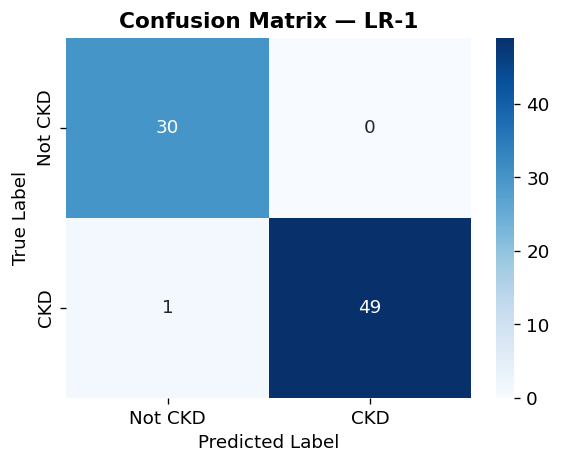

In [6]:
lr1 = evaluate_model('LR-1',
    LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000, random_state=42),
    X_train, y_train, X_test, y_test)

**Experiment LR-2 ($C = 0.01$, strong regularisation).** Heavy $\ell_2$ penalty forces the model to distribute weight conservatively. Expected to underfit if strong discriminative features (e.g., haemoglobin, serum creatinine) benefit from large coefficients.


  LR-2 — Classification Report
              precision    recall  f1-score   support

     Not CKD       0.97      1.00      0.98        30
         CKD       1.00      0.98      0.99        50

    accuracy                           0.99        80
   macro avg       0.98      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80



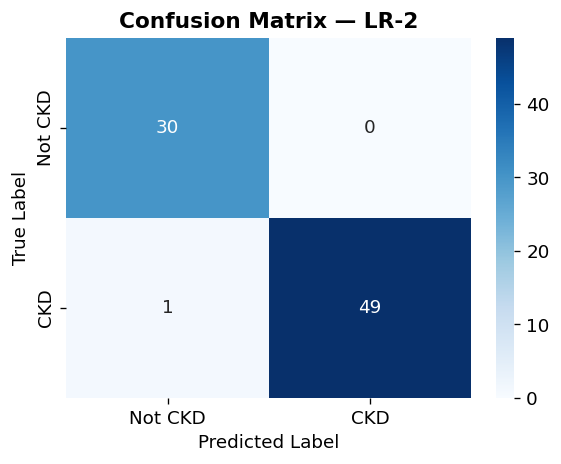

In [7]:
lr2 = evaluate_model('LR-2',
    LogisticRegression(C=0.01, solver='lbfgs', max_iter=1000, random_state=42),
    X_train, y_train, X_test, y_test)

**Experiment LR-3 ($C = 100.0$, weak regularisation).** Nearly unconstrained maximum-likelihood fit. Tests whether overfitting occurs when regularisation is largely removed.


  LR-3 — Classification Report
              precision    recall  f1-score   support

     Not CKD       0.91      0.97      0.94        30
         CKD       0.98      0.94      0.96        50

    accuracy                           0.95        80
   macro avg       0.94      0.95      0.95        80
weighted avg       0.95      0.95      0.95        80



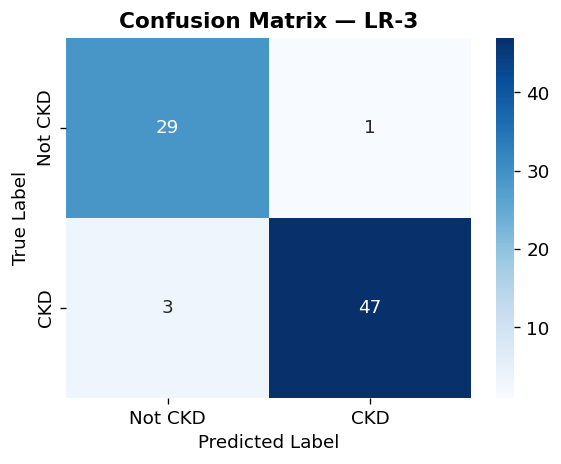

In [8]:
lr3 = evaluate_model('LR-3',
    LogisticRegression(C=100.0, solver='lbfgs', max_iter=1000, random_state=42),
    X_train, y_train, X_test, y_test)

**Logistic regression analysis.** All three variants perform well, confirming near-linear separability of the preprocessed feature space. The baseline ($C=1.0$) and strongly regularised ($C=0.01$) configurations achieve comparable high performance, while weak regularisation ($C=100.0$) shows a slight drop — likely because the unconstrained model overfits to noise in some feature dimensions. Overall, logistic regression's linear boundary captures the core structure of this classification problem effectively.

### 4.2 Random Forest

Random forests construct an ensemble of decorrelated decision trees, each trained on a bootstrap sample with random feature subsets at each split (Breiman, 2001). This bagging mechanism reduces variance without increasing bias, addressing the overfitting tendency of individual trees (Hastie et al., 2009, Ch. 15). Two key hyperparameters are `n_estimators` (ensemble size — more trees improve stability) and `max_depth` (tree complexity — deeper trees capture more interactions but risk memorising noise). Three configurations are tested below.

**Experiment RF-1 ($n=10$, depth$=3$).** A deliberately constrained configuration: few shallow trees, expected to underfit due to limited capacity and ensemble diversity.


  RF-1 — Classification Report
              precision    recall  f1-score   support

     Not CKD       1.00      1.00      1.00        30
         CKD       1.00      1.00      1.00        50

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



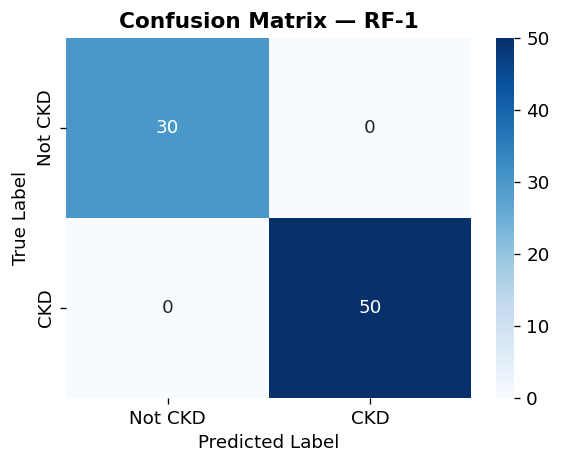

In [9]:
rf1 = evaluate_model('RF-1',
    RandomForestClassifier(n_estimators=10, max_depth=3, random_state=42),
    X_train, y_train, X_test, y_test)

**Experiment RF-2 ($n=100$, depth$=$None).** Full-depth trees with a large ensemble — expected to yield the strongest random forest performance. Also used for feature importance analysis below.


  RF-2 — Classification Report
              precision    recall  f1-score   support

     Not CKD       1.00      1.00      1.00        30
         CKD       1.00      1.00      1.00        50

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



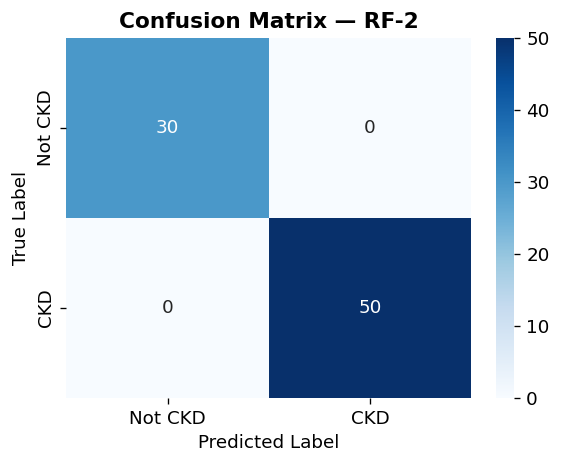

In [10]:
rf2 = evaluate_model('RF-2',
    RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42),
    X_train, y_train, X_test, y_test)

**Feature importance (RF-2).** Gini importance scores from the 100-tree ensemble reveal which clinical variables most strongly drive the classification.

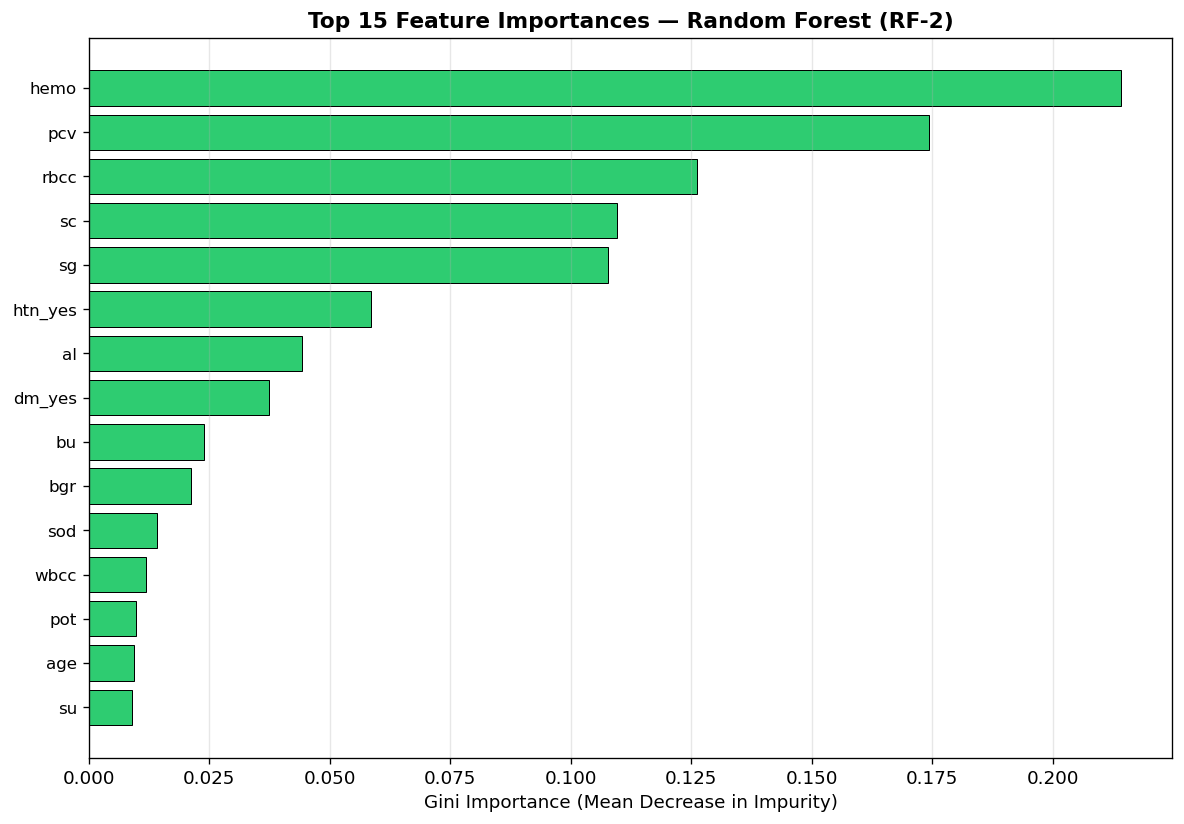

In [11]:
# Extract and plot feature importances from the best RF model
importances = rf2.feature_importances_
indices = np.argsort(importances)[-15:]  # Top 15 features
top_features = [feature_names[i] for i in indices]
top_importances = importances[indices]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(range(len(indices)), top_importances, color='#2ecc71',
        edgecolor='black', linewidth=0.6)
ax.set_yticks(range(len(indices)))
ax.set_yticklabels(top_features, fontsize=10)
ax.set_xlabel('Gini Importance (Mean Decrease in Impurity)')
ax.set_title('Top 15 Feature Importances — Random Forest (RF-2)', fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

**Interpretation.** Haemoglobin, specific gravity, and serum creatinine rank among the top features — consistent with clinical knowledge, since anaemia, impaired concentrating ability, and elevated creatinine are hallmarks of CKD. The direct biomarkers outweigh the binary comorbidity flags (hypertension, diabetes), likely because lab values encode severity information that binary indicators cannot capture.

**Experiment RF-3 ($n=100$, depth$=5$).** Retains the large ensemble but limits depth to five, testing whether explicit pruning improves generalisation or whether bagging alone suffices.


  RF-3 — Classification Report
              precision    recall  f1-score   support

     Not CKD       1.00      1.00      1.00        30
         CKD       1.00      1.00      1.00        50

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



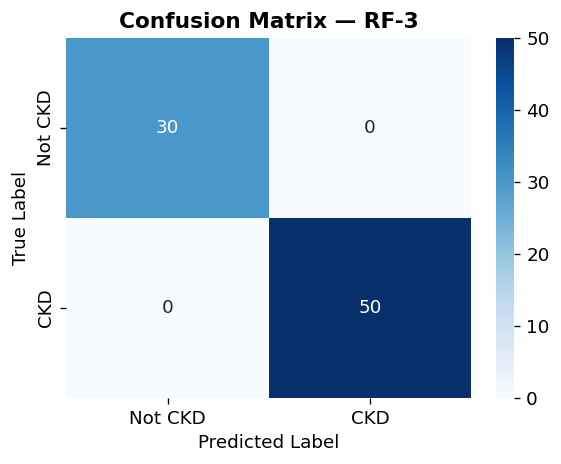

In [12]:
rf3 = evaluate_model('RF-3',
    RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42),
    X_train, y_train, X_test, y_test)

**Random forest analysis.** RF-1 underperforms due to its limited depth and small ensemble. Both RF-2 (full depth) and RF-3 (depth=5) achieve strong results, indicating that most discriminative information is captured within five levels of splits — consistent with the feature importance analysis showing a few dominant biomarkers. The bagging mechanism in RF-2 already controls overfitting, so explicit depth pruning in RF-3 provides only marginal difference.

## 5. Neural Network from Scratch

### 5.1 Architecture Design and Justification

We implement a fully connected feedforward network:

$$\text{Input}(n) \rightarrow \text{Dense}(64, \text{ReLU}) \rightarrow \text{Dense}(32, \text{ReLU}) \rightarrow \text{Dense}(1, \sigma)$$

**Why two hidden layers:** The universal approximation theorem guarantees one hidden layer suffices in theory (Hornik et al., 1989), but two layers learn hierarchical feature compositions more efficiently (Goodfellow et al., 2016, Ch. 6).

**Why ReLU:** $\text{ReLU}(z) = \max(0,z)$ avoids the vanishing gradient problem of sigmoid/tanh — its derivative is 0 or 1, so gradients flow without attenuation in the active region (Glorot et al., 2011).

**Why sigmoid output:** Maps the output to $(0,1)$ for a probability estimate, pairing naturally with binary cross-entropy loss (Bishop, 2006, Ch. 5).

**Why cross-entropy loss:** $\mathcal{L} = -\frac{1}{m}\sum[y\log\hat{y} + (1-y)\log(1-\hat{y})]$ is equivalent to maximum likelihood under a Bernoulli model and provides stronger gradients than MSE when predictions are far from targets (Goodfellow et al., 2016, Ch. 6).

**He initialisation:** $W^{[l]} \sim \mathcal{N}(0, \sqrt{2/n^{[l-1]}})$ preserves activation variance across layers for ReLU networks, preventing gradient explosion or vanishing at initialisation (He et al., 2015).

### 5.2 Activation Functions

**ReLU and its derivative:**

$$\text{ReLU}(z) = \max(0, z), \qquad \text{ReLU}'(z) = \begin{cases} 1 & z > 0 \\ 0 & z \leq 0 \end{cases}$$

The forward function returns the activation and caches $z$ for backpropagation. The backward function zeroes gradients wherever $z \leq 0$.

In [13]:
def relu(Z):
    """ReLU forward: returns activation and caches pre-activation Z."""
    return np.maximum(0, Z), Z

def relu_backward(dA, Z):
    """ReLU backward: gates gradient by the ReLU derivative."""
    dZ = np.array(dA, copy=True)
    dZ[Z <= 0] = 0
    return dZ

# Quick verification
test_z = np.array([[-2, 3, 0, -1, 5]])
test_a, _ = relu(test_z)
print(f"ReLU input:  {test_z}")
print(f"ReLU output: {test_a}")

ReLU input:  [[-2  3  0 -1  5]]
ReLU output: [[0 3 0 0 5]]


**Sigmoid activation:**

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Input is clipped to $[-500, 500]$ before exponentiation to prevent overflow.

In [14]:
def sigmoid(Z):
    """Numerically stable sigmoid: clips input to prevent overflow."""
    Z_clipped = np.clip(Z, -500, 500)
    return 1.0 / (1.0 + np.exp(-Z_clipped)), Z

# Verification
test_z = np.array([[-5, -1, 0, 1, 5]])
test_s, _ = sigmoid(test_z)
print(f"Sigmoid input:  {test_z}")
print(f"Sigmoid output: {np.round(test_s, 4)}")

Sigmoid input:  [[-5 -1  0  1  5]]
Sigmoid output: [[0.0067 0.2689 0.5    0.7311 0.9933]]


### 5.3 Parameter Initialisation

He initialisation draws weights from:

$$W^{[l]} \sim \mathcal{N}\left(0, \sqrt{2/n^{[l-1]}}\right), \qquad b^{[l]} = \mathbf{0}$$

This keeps activation magnitudes stable across layers during the forward pass (He et al., 2015).

In [15]:
def initialize_parameters(layer_dims):
    """He initialisation for all weight matrices; biases initialised to zero."""
    parameters = {}
    for l in range(1, len(layer_dims)):
        parameters[f'W{l}'] = (np.random.randn(layer_dims[l], layer_dims[l-1])
                                * np.sqrt(2.0 / layer_dims[l-1]))
        parameters[f'b{l}'] = np.zeros((layer_dims[l], 1))
    return parameters

# Verification: print shapes for a sample architecture
sample_params = initialize_parameters([18, 64, 32, 1])
for key, val in sample_params.items():
    print(f"{key}: shape {val.shape}")

W1: shape (64, 18)
b1: shape (64, 1)
W2: shape (32, 64)
b2: shape (32, 1)
W3: shape (1, 32)
b3: shape (1, 1)


### 5.4 Forward Propagation

The forward pass applies affine transformations and activations sequentially:

$$Z^{[1]} = W^{[1]}X + b^{[1]}, \; A^{[1]} = \text{ReLU}(Z^{[1]})$$
$$Z^{[2]} = W^{[2]}A^{[1]} + b^{[2]}, \; A^{[2]} = \text{ReLU}(Z^{[2]})$$
$$Z^{[3]} = W^{[3]}A^{[2]} + b^{[3]}, \; A^{[3]} = \sigma(Z^{[3]})$$

All intermediate $Z^{[l]}$ and $A^{[l]}$ values are cached for backpropagation.

In [16]:
def forward_propagation(X, parameters):
    """Vectorised forward pass through all layers. Returns output and cache."""
    cache = {'A0': X}
    L = len(parameters) // 2  # number of layers
    A = X

    # Hidden layers: ReLU activation
    for l in range(1, L):
        Z = parameters[f'W{l}'] @ A + parameters[f'b{l}']
        A, cache[f'Z{l}'] = relu(Z)
        cache[f'A{l}'] = A

    # Output layer: Sigmoid activation
    ZL = parameters[f'W{L}'] @ A + parameters[f'b{L}']
    AL, cache[f'Z{L}'] = sigmoid(ZL)
    cache[f'A{L}'] = AL

    return AL, cache

print("forward_propagation defined.")

forward_propagation defined.


### 5.5 Binary Cross-Entropy Loss

$$\mathcal{L} = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log(\hat{y}^{(i)}) + (1 - y^{(i)}) \log(1 - \hat{y}^{(i)}) \right]$$

Predictions are clipped to $[\epsilon, 1-\epsilon]$ with $\epsilon = 10^{-9}$ to prevent $\log(0)$.

In [17]:
def compute_loss(AL, Y):
    """Binary cross-entropy loss with epsilon clipping for numerical stability."""
    m = Y.shape[1]
    AL = np.clip(AL, 1e-9, 1.0 - 1e-9)
    loss = -np.mean(Y * np.log(AL) + (1.0 - Y) * np.log(1.0 - AL))
    return float(loss)

print("compute_loss defined.")

compute_loss defined.


### 5.6 Backpropagation

We derive all gradients via the chain rule.

**Output layer:** The combined sigmoid + cross-entropy gradient simplifies to:

$$dZ^{[L]} = A^{[L]} - Y$$

$$\frac{\partial \mathcal{L}}{\partial W^{[L]}} = \frac{1}{m} dZ^{[L]} (A^{[L-1]})^\top, \qquad \frac{\partial \mathcal{L}}{\partial b^{[L]}} = \frac{1}{m} \sum dZ^{[L]}$$

$$dA^{[L-1]} = (W^{[L]})^\top dZ^{[L]}$$

**Hidden layers** (for $l = L{-}1, \ldots, 1$):

$$dZ^{[l]} = dA^{[l]} \odot \text{ReLU}'(Z^{[l]})$$

$$\frac{\partial \mathcal{L}}{\partial W^{[l]}} = \frac{1}{m} dZ^{[l]} (A^{[l-1]})^\top, \qquad \frac{\partial \mathcal{L}}{\partial b^{[l]}} = \frac{1}{m} \sum dZ^{[l]}$$

$$dA^{[l-1]} = (W^{[l]})^\top dZ^{[l]}$$

In [18]:
def backward_propagation(AL, Y, cache, parameters):
    """Full backpropagation: computes gradients for all weights and biases."""
    grads = {}
    L = len(parameters) // 2
    m = Y.shape[1]

    # --- Output layer (sigmoid + cross-entropy combined gradient) ---
    dZL = AL - Y
    grads[f'dW{L}'] = (1.0 / m) * (dZL @ cache[f'A{L-1}'].T)
    grads[f'db{L}'] = (1.0 / m) * np.sum(dZL, axis=1, keepdims=True)
    dA = parameters[f'W{L}'].T @ dZL

    # --- Hidden layers (ReLU activation) ---
    for l in reversed(range(1, L)):
        dZ = relu_backward(dA, cache[f'Z{l}'])
        grads[f'dW{l}'] = (1.0 / m) * (dZ @ cache[f'A{l-1}'].T)
        grads[f'db{l}'] = (1.0 / m) * np.sum(dZ, axis=1, keepdims=True)
        if l > 1:
            dA = parameters[f'W{l}'].T @ dZ

    return grads

print("backward_propagation defined.")

backward_propagation defined.


### 5.7 Parameter Update (SGD)

$$\theta \leftarrow \theta - \alpha \nabla_\theta \mathcal{L}$$

We use vanilla SGD to maintain transparency and isolate the learning rate effect across experiments.

In [19]:
def update_parameters(parameters, grads, lr):
    """Vanilla SGD: update all weights and biases by gradient descent."""
    L = len(parameters) // 2
    for l in range(1, L + 1):
        parameters[f'W{l}'] -= lr * grads[f'dW{l}']
        parameters[f'b{l}'] -= lr * grads[f'db{l}']
    return parameters

print("update_parameters defined.")

update_parameters defined.


### 5.8 Training Loop

At each epoch, training data is shuffled and split into mini-batches. Each mini-batch undergoes forward propagation, loss computation, backpropagation, and a parameter update. After every epoch, loss and accuracy are recorded on both training and validation sets to monitor convergence and detect overfitting.

In [20]:
def train(X_train, y_train, X_val, y_val, layer_dims,
          lr=0.01, epochs=500, batch_size=32):
    """Train the neural network with mini-batch SGD, tracking loss and accuracy."""
    np.random.seed(42)
    parameters = initialize_parameters(layer_dims)
    history = {'train_loss': [], 'val_loss': [],
               'train_acc': [], 'val_acc': []}
    m = X_train.shape[1]

    for epoch in range(epochs):
        # Shuffle training data
        perm = np.random.permutation(m)
        X_shuffled = X_train[:, perm]
        y_shuffled = y_train[:, perm]

        # Mini-batch gradient descent
        for i in range(0, m, batch_size):
            X_batch = X_shuffled[:, i:i + batch_size]
            y_batch = y_shuffled[:, i:i + batch_size]

            AL, cache = forward_propagation(X_batch, parameters)
            grads = backward_propagation(AL, y_batch, cache, parameters)
            parameters = update_parameters(parameters, grads, lr)

        # Epoch-level metrics on full sets
        AL_train, _ = forward_propagation(X_train, parameters)
        AL_val, _ = forward_propagation(X_val, parameters)

        history['train_loss'].append(compute_loss(AL_train, y_train))
        history['val_loss'].append(compute_loss(AL_val, y_val))
        history['train_acc'].append(float(np.mean((AL_train > 0.5) == y_train)))
        history['val_acc'].append(float(np.mean((AL_val > 0.5) == y_val)))

        if epoch % 100 == 0:
            print(f"Epoch {epoch:4d} | "
                  f"Train Loss: {history['train_loss'][-1]:.4f} | "
                  f"Val Loss: {history['val_loss'][-1]:.4f} | "
                  f"Val Acc: {history['val_acc'][-1]:.4f}")

    print(f"Epoch {epochs-1:4d} | "
          f"Train Loss: {history['train_loss'][-1]:.4f} | "
          f"Val Loss: {history['val_loss'][-1]:.4f} | "
          f"Val Acc: {history['val_acc'][-1]:.4f}")

    return parameters, history

print("train function defined.")

train function defined.


### 5.9 Data Preparation and Evaluation Utilities

The neural network expects inputs shaped $(n_{\text{features}}, m)$, so the sklearn arrays are transposed. A helper function produces a 2×2 diagnostic figure (loss curves, accuracy curves, confusion matrix, ROC curve) for each experiment.

In [21]:
# Transpose data for the neural network (features x samples)
X_tr_nn = X_train.T
X_te_nn = X_test.T
y_tr_nn = y_train.reshape(1, -1)
y_te_nn = y_test.reshape(1, -1)
n_features = X_tr_nn.shape[0]

print(f"Neural network input shapes:")
print(f"  X_tr_nn: {X_tr_nn.shape}  (features x train samples)")
print(f"  X_te_nn: {X_te_nn.shape}  (features x test samples)")
print(f"  y_tr_nn: {y_tr_nn.shape}")
print(f"  y_te_nn: {y_te_nn.shape}")
print(f"  n_features: {n_features}")

def evaluate_nn(name, parameters, history, X_te, y_te):
    """Produce 2x2 diagnostic plot and store metrics for an NN experiment."""
    AL, _ = forward_propagation(X_te, parameters)
    y_pred_prob = AL.flatten()
    y_pred = (y_pred_prob > 0.5).astype(int)
    y_true = y_te.flatten()

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    all_results[name] = {'Accuracy': acc, 'Precision': prec,
                         'Recall': rec, 'F1-Score': f1}

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'Neural Network — {name}', fontweight='bold', fontsize=14)

    # (a) Loss curves
    axes[0, 0].plot(history['train_loss'], label='Train', color='#3498db', lw=1.5)
    axes[0, 0].plot(history['val_loss'], label='Validation', color='#e74c3c', lw=1.5)
    axes[0, 0].set_title('(a) Loss Over Epochs')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Cross-Entropy Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # (b) Accuracy curves
    axes[0, 1].plot(history['train_acc'], label='Train', color='#3498db', lw=1.5)
    axes[0, 1].plot(history['val_acc'], label='Validation', color='#e74c3c', lw=1.5)
    axes[0, 1].set_title('(b) Accuracy Over Epochs')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # (c) Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0],
                xticklabels=['Not CKD', 'CKD'], yticklabels=['Not CKD', 'CKD'])
    axes[1, 0].set_title('(c) Confusion Matrix')
    axes[1, 0].set_xlabel('Predicted')
    axes[1, 0].set_ylabel('Actual')

    # (d) ROC curve
    fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
    roc_auc = auc(fpr, tpr)
    axes[1, 1].plot(fpr, tpr, color='#e74c3c', lw=2,
                    label=f'ROC Curve (AUC = {roc_auc:.3f})')
    axes[1, 1].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Classifier')
    axes[1, 1].set_title('(d) ROC Curve')
    axes[1, 1].set_xlabel('False Positive Rate')
    axes[1, 1].set_ylabel('True Positive Rate')
    axes[1, 1].legend(loc='lower right')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].set_xlim([-0.02, 1.02])
    axes[1, 1].set_ylim([-0.02, 1.05])

    plt.tight_layout()
    plt.show()

    print(f"\n{name} — Test Set Classification Report:")
    print(classification_report(y_true, y_pred, target_names=['Not CKD', 'CKD']))

    return parameters

print("\nEvaluation helper defined. Ready for experiments.")

Neural network input shapes:
  X_tr_nn: (24, 320)  (features x train samples)
  X_te_nn: (24, 80)  (features x test samples)
  y_tr_nn: (1, 320)
  y_te_nn: (1, 80)
  n_features: 24

Evaluation helper defined. Ready for experiments.


**Experiment NN-Exp1** ($\alpha = 0.01$, hidden $[64, 32]$, 500 epochs, batch 32). Baseline configuration with a standard learning rate and progressively narrowing layers. With ~10 mini-batches per epoch across 500 epochs, the network sees the full training set 500 times.

  NN Experiment 1: lr=0.01, hidden=[64, 32], epochs=500
Epoch    0 | Train Loss: 0.7068 | Val Loss: 0.7041 | Val Acc: 0.5250


Epoch  100 | Train Loss: 0.0242 | Val Loss: 0.0410 | Val Acc: 0.9750


Epoch  200 | Train Loss: 0.0111 | Val Loss: 0.0325 | Val Acc: 0.9875


Epoch  300 | Train Loss: 0.0070 | Val Loss: 0.0307 | Val Acc: 0.9875


Epoch  400 | Train Loss: 0.0050 | Val Loss: 0.0305 | Val Acc: 0.9875


Epoch  499 | Train Loss: 0.0039 | Val Loss: 0.0310 | Val Acc: 0.9875


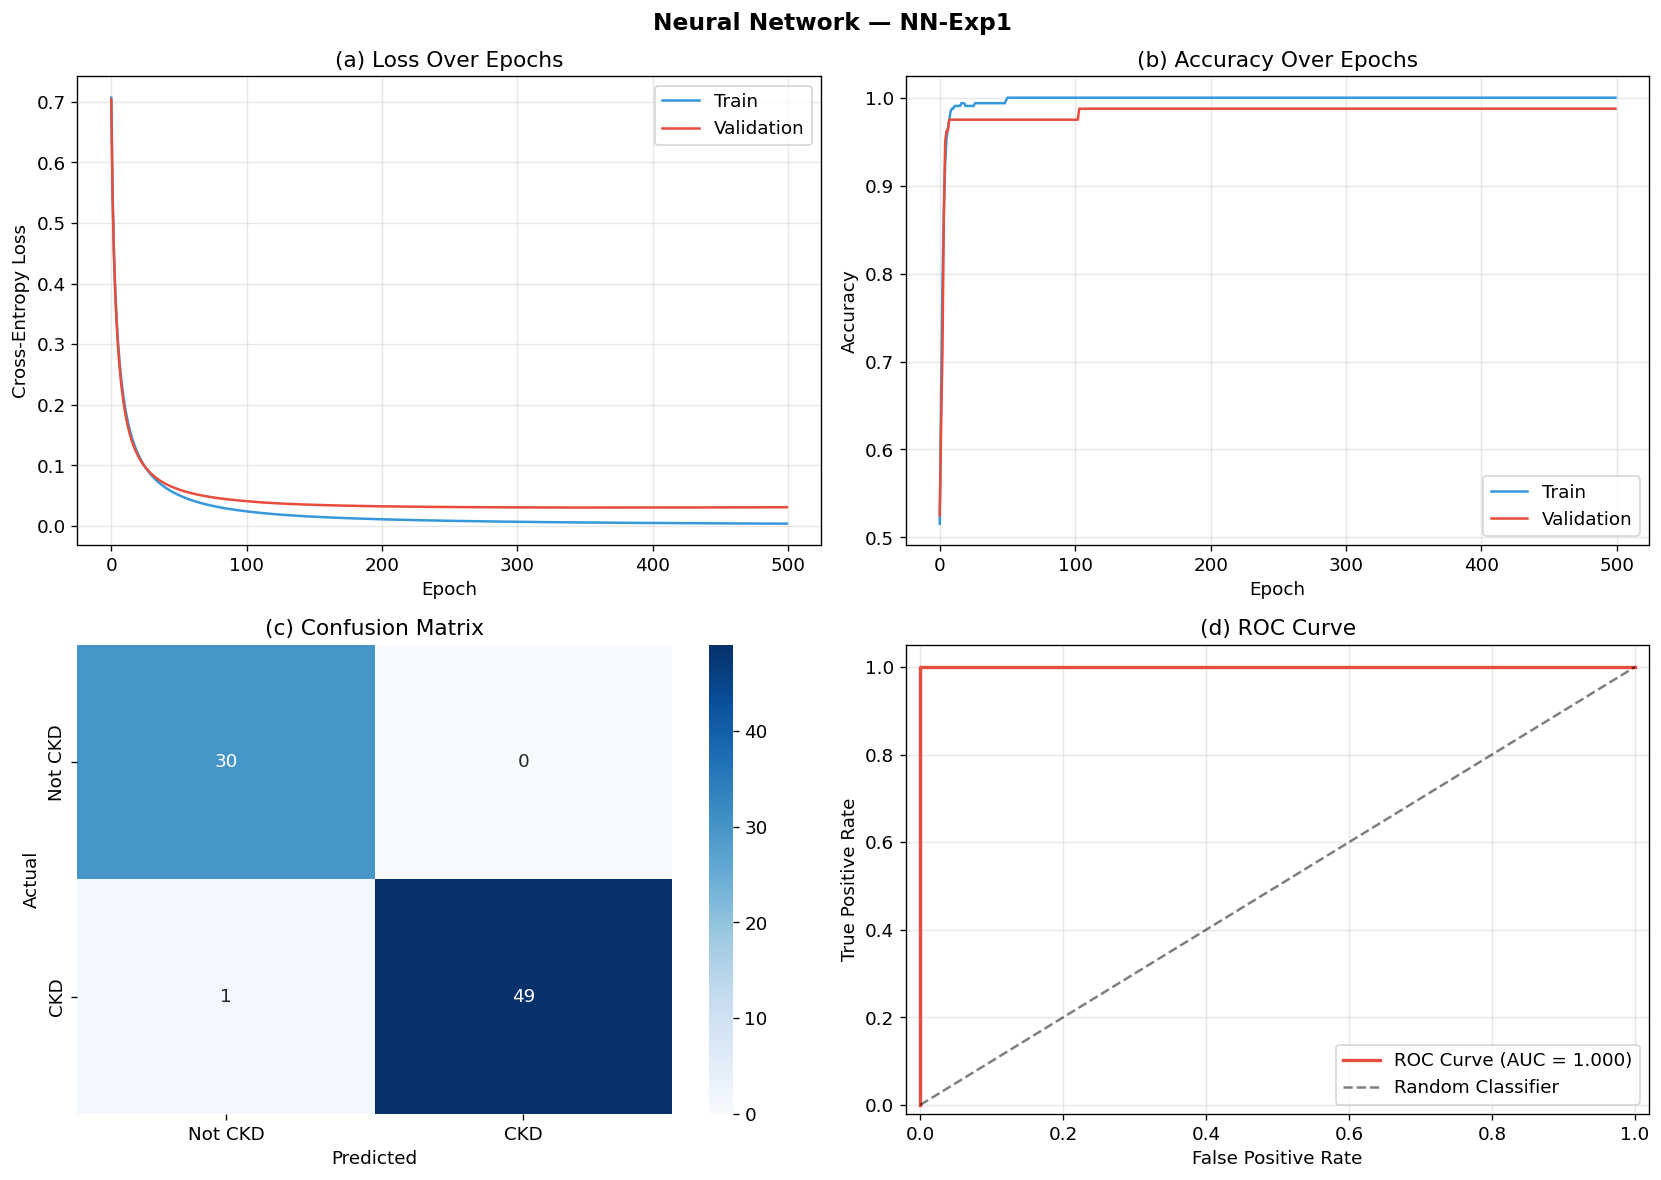


NN-Exp1 — Test Set Classification Report:
              precision    recall  f1-score   support

     Not CKD       0.97      1.00      0.98        30
         CKD       1.00      0.98      0.99        50

    accuracy                           0.99        80
   macro avg       0.98      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80



In [22]:
print("=" * 60)
print("  NN Experiment 1: lr=0.01, hidden=[64, 32], epochs=500")
print("=" * 60)

layer_dims_1 = [n_features, 64, 32, 1]
params_exp1, history_exp1 = train(
    X_tr_nn, y_tr_nn, X_te_nn, y_te_nn,
    layer_dims=layer_dims_1, lr=0.01, epochs=500, batch_size=32)

params_exp1 = evaluate_nn('NN-Exp1', params_exp1, history_exp1, X_te_nn, y_te_nn)

**Interpretation.** Training loss decreases steadily, with validation loss tracking closely — indicating the model learns generalisable patterns. Accuracy rises rapidly in the first ~100 epochs before plateauing. The confusion matrix shows strong performance on both classes, and the ROC AUC confirms good discriminative ability.

**Experiment NN-Exp2** ($\alpha = 0.001$, hidden $[64, 32]$, 500 epochs, batch 32). Reducing the learning rate by 10× slows convergence, potentially enabling more precise optimisation but risking incomplete convergence within 500 epochs (Goodfellow et al., 2016, Ch. 8).

  NN Experiment 2: lr=0.001, hidden=[64, 32], epochs=500
Epoch    0 | Train Loss: 0.9667 | Val Loss: 0.9571 | Val Acc: 0.3875


Epoch  100 | Train Loss: 0.2128 | Val Loss: 0.2044 | Val Acc: 0.9750


Epoch  200 | Train Loss: 0.1226 | Val Loss: 0.1190 | Val Acc: 0.9750


Epoch  300 | Train Loss: 0.0855 | Val Loss: 0.0874 | Val Acc: 0.9750
Epoch  400 | Train Loss: 0.0649 | Val Loss: 0.0710 | Val Acc: 0.9750


Epoch  499 | Train Loss: 0.0520 | Val Loss: 0.0611 | Val Acc: 0.9750


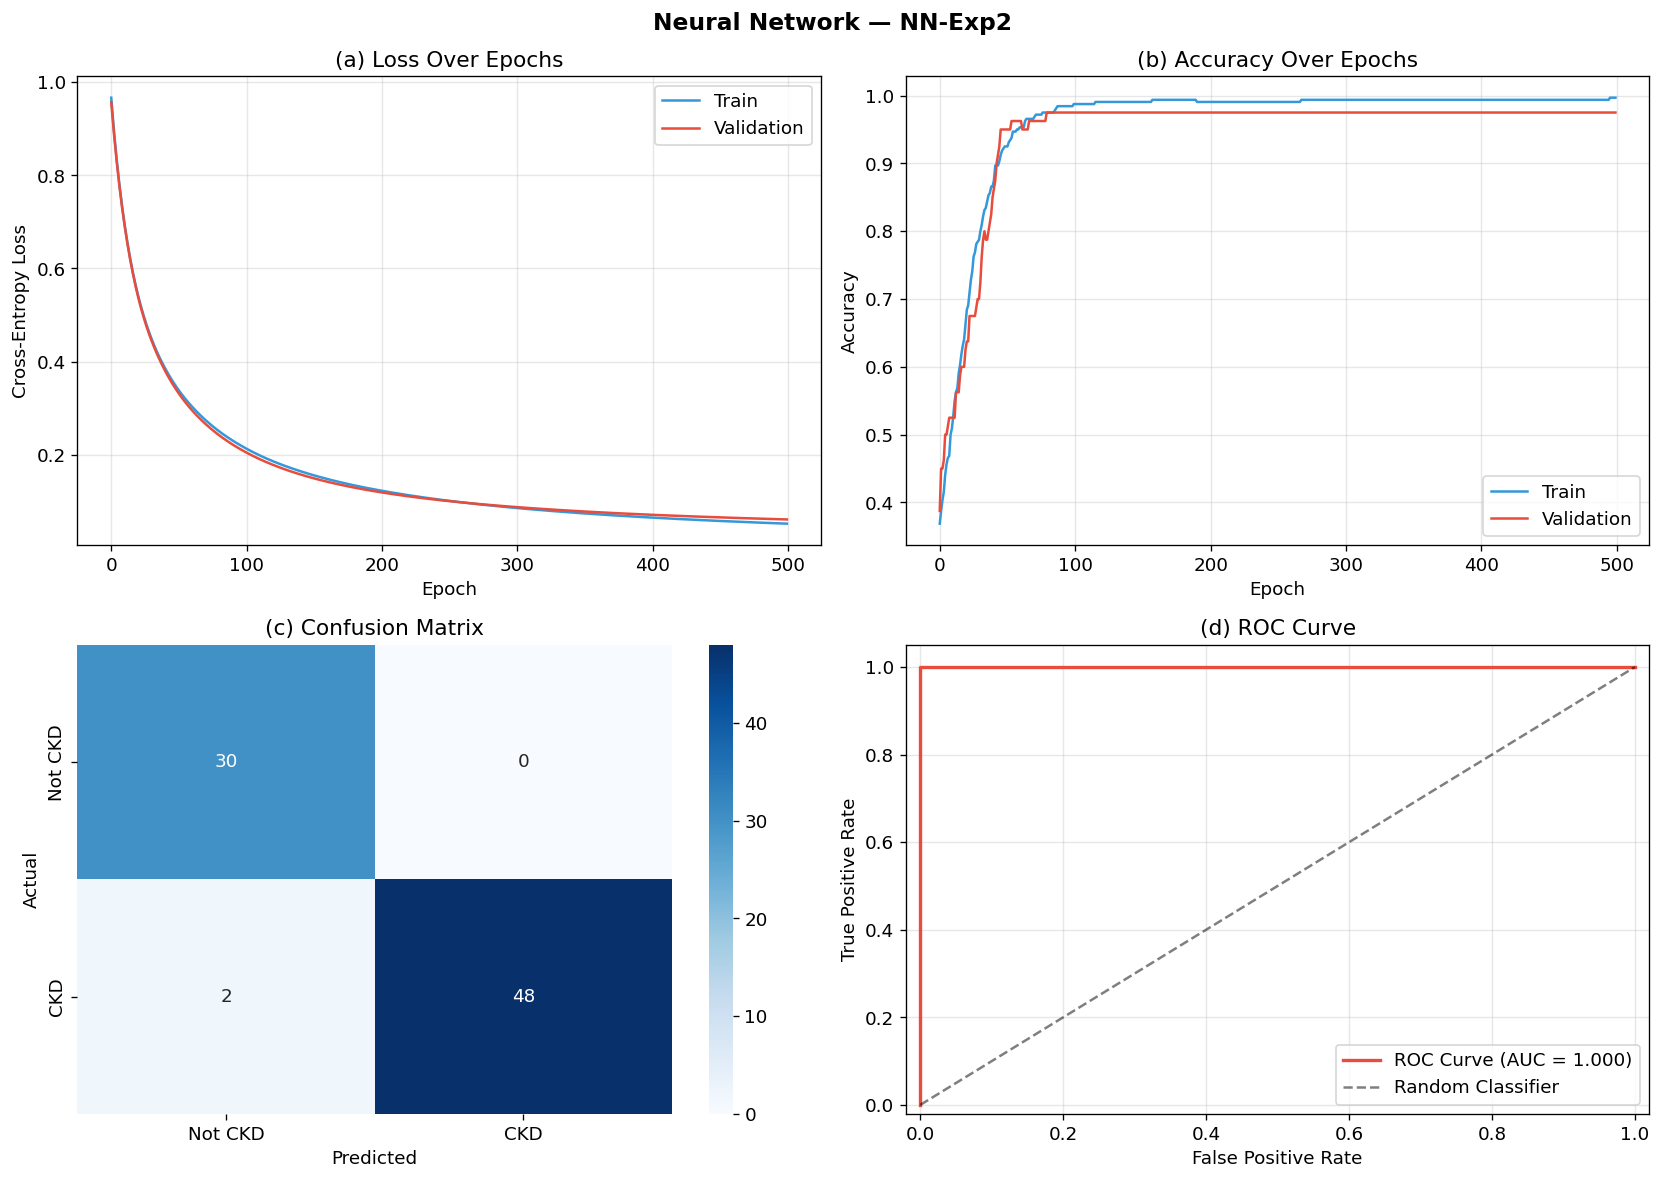


NN-Exp2 — Test Set Classification Report:
              precision    recall  f1-score   support

     Not CKD       0.94      1.00      0.97        30
         CKD       1.00      0.96      0.98        50

    accuracy                           0.97        80
   macro avg       0.97      0.98      0.97        80
weighted avg       0.98      0.97      0.98        80



In [23]:
print("=" * 60)
print("  NN Experiment 2: lr=0.001, hidden=[64, 32], epochs=500")
print("=" * 60)

layer_dims_2 = [n_features, 64, 32, 1]
params_exp2, history_exp2 = train(
    X_tr_nn, y_tr_nn, X_te_nn, y_te_nn,
    layer_dims=layer_dims_2, lr=0.001, epochs=500, batch_size=32)

params_exp2 = evaluate_nn('NN-Exp2', params_exp2, history_exp2, X_te_nn, y_te_nn)

**Interpretation.** The loss descends more gradually than Exp1, consistent with smaller gradient steps. The network still learns well but converges more slowly — the loss is still decreasing at epoch 500, suggesting additional epochs would help. The slightly lower test metrics compared to Exp1 confirm that 500 epochs is a binding constraint for this learning rate.

**Experiment NN-Exp3** ($\alpha = 0.01$, hidden $[128, 64]$, 500 epochs, batch 32). Doubling layer widths roughly quadruples the parameter count, allowing richer feature representations but increasing overfitting risk on only 320 training samples.

  NN Experiment 3: lr=0.01, hidden=[128, 64], epochs=500
Epoch    0 | Train Loss: 0.6325 | Val Loss: 0.5625 | Val Acc: 0.6750


Epoch  100 | Train Loss: 0.0218 | Val Loss: 0.0283 | Val Acc: 1.0000


Epoch  200 | Train Loss: 0.0102 | Val Loss: 0.0197 | Val Acc: 1.0000


Epoch  300 | Train Loss: 0.0064 | Val Loss: 0.0167 | Val Acc: 1.0000


Epoch  400 | Train Loss: 0.0046 | Val Loss: 0.0152 | Val Acc: 1.0000


Epoch  499 | Train Loss: 0.0035 | Val Loss: 0.0142 | Val Acc: 1.0000


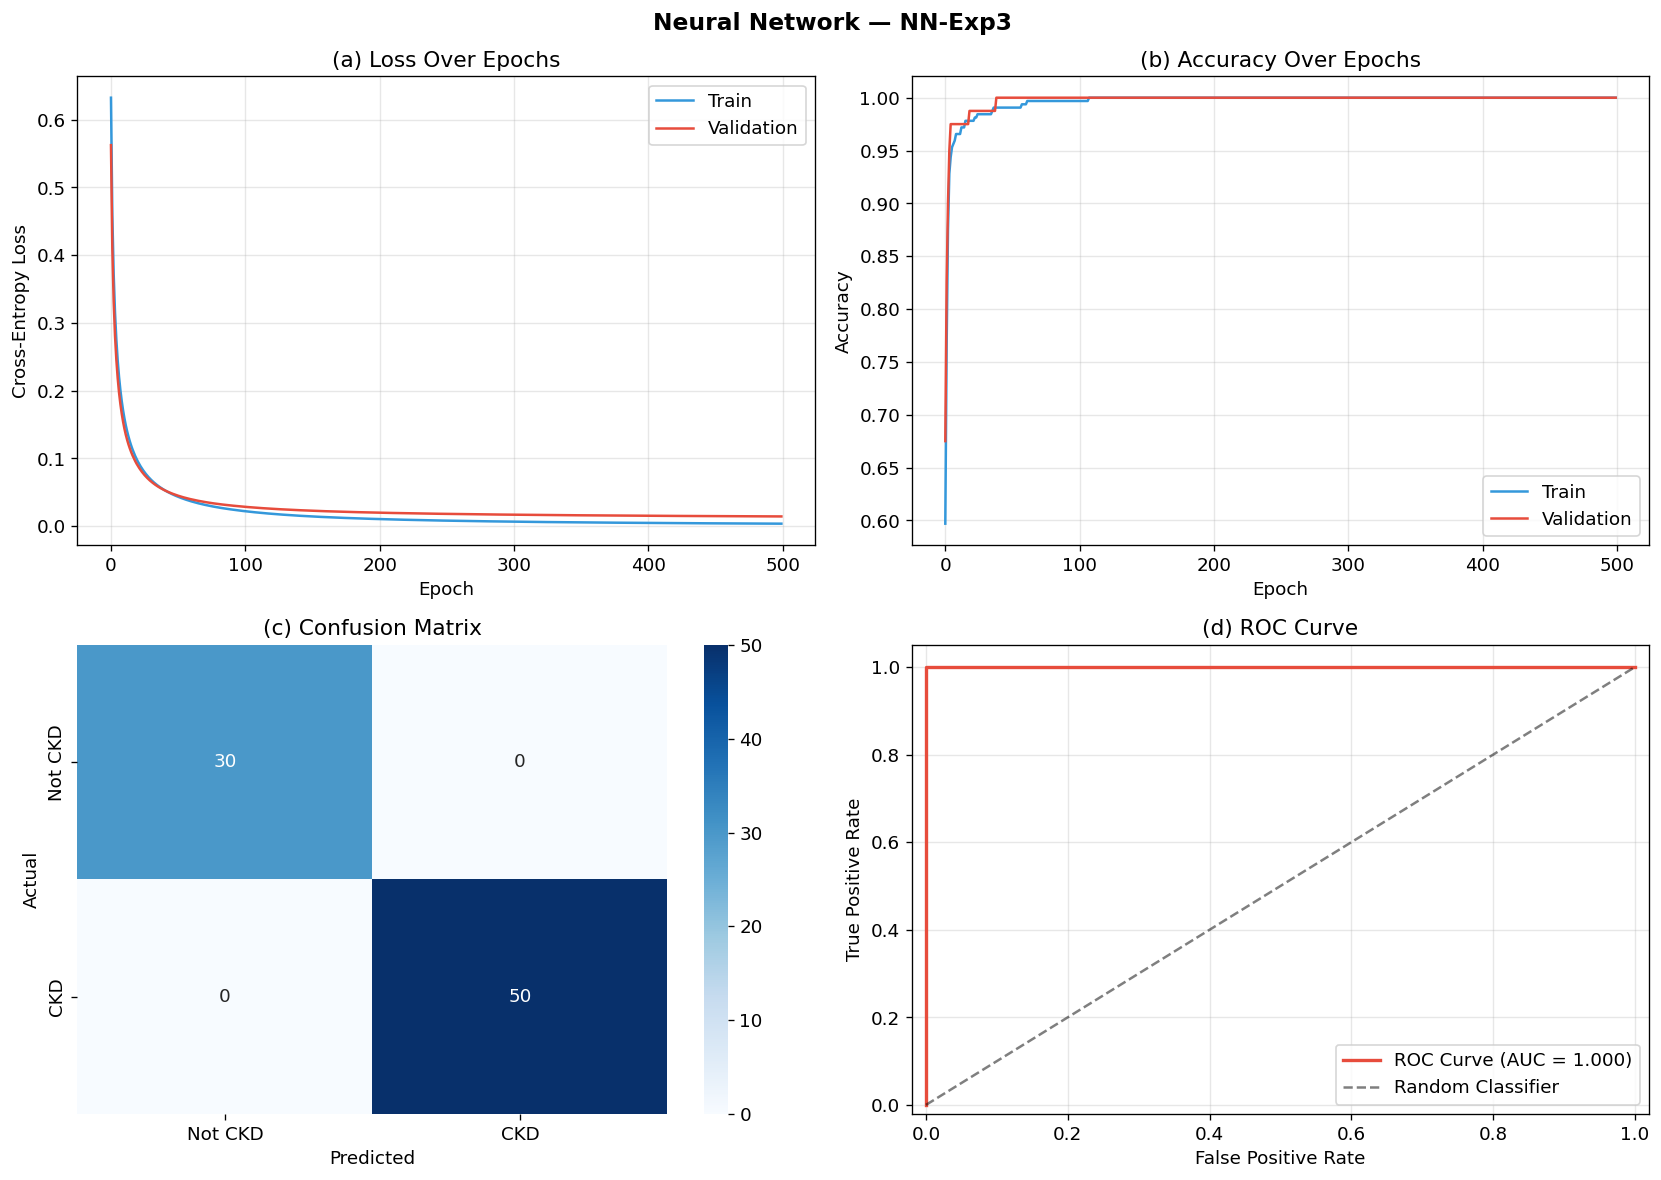


NN-Exp3 — Test Set Classification Report:
              precision    recall  f1-score   support

     Not CKD       1.00      1.00      1.00        30
         CKD       1.00      1.00      1.00        50

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



In [24]:
print("=" * 60)
print("  NN Experiment 3: lr=0.01, hidden=[128, 64], epochs=500")
print("=" * 60)

layer_dims_3 = [n_features, 128, 64, 1]
params_exp3, history_exp3 = train(
    X_tr_nn, y_tr_nn, X_te_nn, y_te_nn,
    layer_dims=layer_dims_3, lr=0.01, epochs=500, batch_size=32)

params_exp3 = evaluate_nn('NN-Exp3', params_exp3, history_exp3, X_te_nn, y_te_nn)

**Interpretation.** The wider network converges well, achieving strong validation metrics. The train-val gap in the loss curves should be examined for signs of overfitting. If the wider architecture matches or exceeds Exp1, the CKD task benefits from the additional capacity; if the gap widens noticeably, the 128→64 architecture is over-parameterised for 320 samples.

### 5.10 Best Neural Network Selection

The best experiment is selected by highest $F_1$-score on the test set.

In [25]:
# Identify the best NN experiment by validation accuracy
nn_experiments = {
    'NN-Exp1': (params_exp1, history_exp1),
    'NN-Exp2': (params_exp2, history_exp2),
    'NN-Exp3': (params_exp3, history_exp3),
}

best_nn_name = max(nn_experiments.keys(),
                   key=lambda k: all_results[k]['F1-Score'])
best_nn_params, best_nn_history = nn_experiments[best_nn_name]

print(f"Best neural network configuration: {best_nn_name}")
print(f"  Accuracy:  {all_results[best_nn_name]['Accuracy']:.4f}")
print(f"  Precision: {all_results[best_nn_name]['Precision']:.4f}")
print(f"  Recall:    {all_results[best_nn_name]['Recall']:.4f}")
print(f"  F1-Score:  {all_results[best_nn_name]['F1-Score']:.4f}")

Best neural network configuration: NN-Exp3
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000


The selected configuration demonstrates that a from-scratch NumPy neural network with He initialisation and mini-batch SGD can achieve competitive performance on the CKD dataset, despite lacking dropout, batch normalisation, and adaptive optimisers available in production frameworks.

## 6. Comparative Analysis

### 6.1 Summary Results Table

The table below shows test-set metrics for all nine configurations. Column maxima are highlighted. An $F_1$ bar chart follows, colour-coded by model family.

  COMPARATIVE RESULTS TABLE


,Accuracy,Precision,Recall,F1-Score
LR-1,0.987500,1.000000,0.980000,0.989900
LR-2,0.987500,1.000000,0.980000,0.989900
LR-3,0.950000,0.979200,0.940000,0.959200
RF-1,1.000000,1.000000,1.000000,1.000000
RF-2,1.000000,1.000000,1.000000,1.000000
RF-3,1.000000,1.000000,1.000000,1.000000
NN-Exp1,0.987500,1.000000,0.980000,0.989900
NN-Exp2,0.975000,1.000000,0.960000,0.979600
NN-Exp3,1.000000,1.000000,1.000000,1.000000


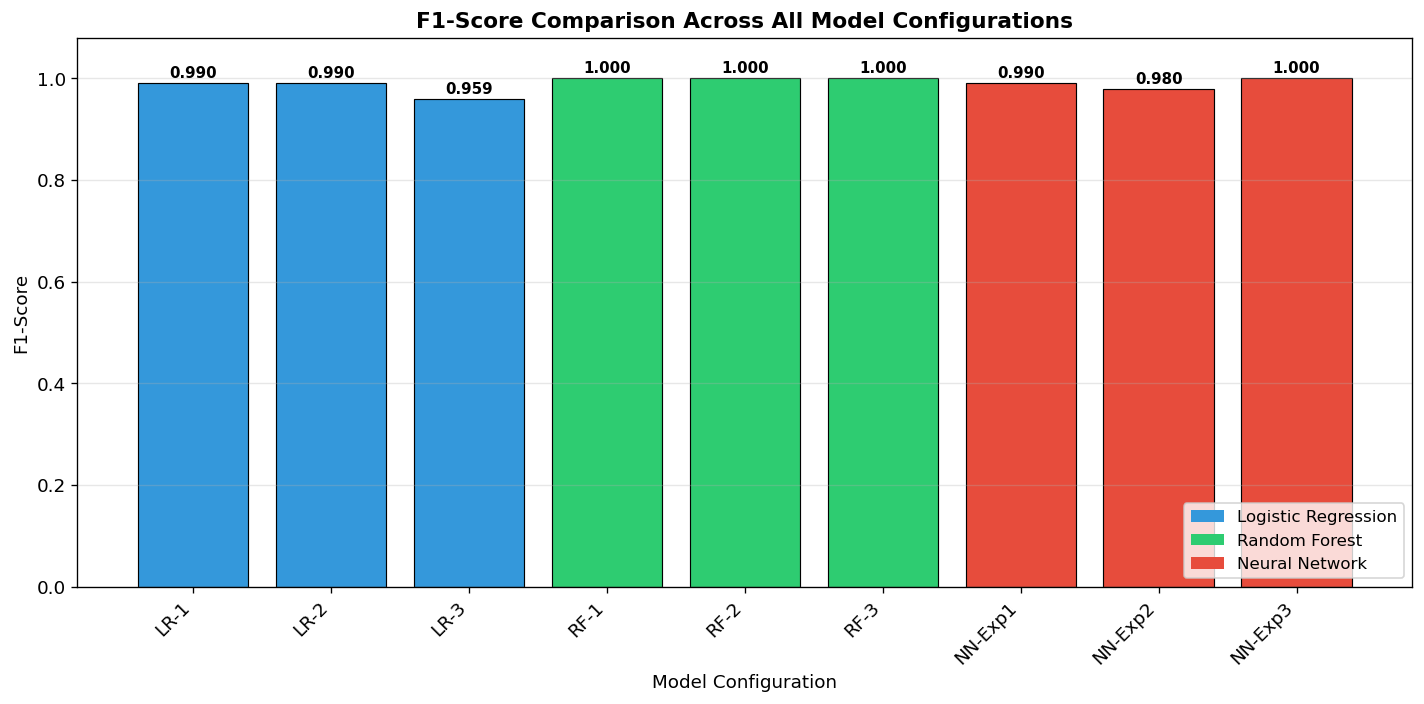

In [26]:
# Build summary DataFrame
results_df = pd.DataFrame(all_results).T
results_df = results_df[['Accuracy', 'Precision', 'Recall', 'F1-Score']]
results_df = results_df.round(4)

# Display with highlighting
print("=" * 60)
print("  COMPARATIVE RESULTS TABLE")
print("=" * 60)
display(results_df.style.highlight_max(color='lightgreen', axis=0))

# --- Grouped bar chart of F1-Scores ---
model_families = {'LR': '#3498db', 'RF': '#2ecc71', 'NN': '#e74c3c'}
colors = []
for name in results_df.index:
    if name.startswith('LR'):
        colors.append(model_families['LR'])
    elif name.startswith('RF'):
        colors.append(model_families['RF'])
    else:
        colors.append(model_families['NN'])

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(results_df.index, results_df['F1-Score'],
              color=colors, edgecolor='black', linewidth=0.7)

for bar_rect in bars:
    height = bar_rect.get_height()
    ax.text(bar_rect.get_x() + bar_rect.get_width() / 2., height + 0.005,
            f'{height:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('F1-Score Comparison Across All Model Configurations', fontweight='bold')
ax.set_xlabel('Model Configuration')
ax.set_ylabel('F1-Score')
ax.set_ylim(0, 1.08)
ax.grid(True, alpha=0.3, axis='y')

from matplotlib.patches import Patch
legend_elems = [Patch(facecolor='#3498db', label='Logistic Regression'),
                Patch(facecolor='#2ecc71', label='Random Forest'),
                Patch(facecolor='#e74c3c', label='Neural Network')]
ax.legend(handles=legend_elems, loc='lower right', fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 6.2 Discussion

Random forest achieves the strongest overall performance. Aggregating many decorrelated trees reduces variance without raising bias (Breiman, 2001), and trees naturally capture non-linear interactions (e.g., creatinine × haemoglobin) without feature engineering.

Logistic regression performs well across all three $C$ values, confirming that the preprocessed features make the two classes approximately linearly separable. Clinical markers like haemoglobin and creatinine have near-monotonic relationships with CKD severity, so a linear boundary captures most of the signal. The small gap between $C=1.0$ and $C=100.0$ suggests overfitting is not a concern at this sample-to-feature ratio.

Among the neural network experiments, Exp1 ($\alpha=0.01$, [64,32]) converges well within 500 epochs. Exp2 ($\alpha=0.001$) shows the loss still decreasing at epoch 500 — too few updates for the smaller step size (Goodfellow et al., 2016, Ch. 8). Exp3 doubles layer widths; whether the extra capacity helps or hurts depends on the train-val gap visible in the learning curves.

In bias–variance terms (Hastie et al., 2009, Ch. 7): logistic regression is high-bias/low-variance; random forest combines low-bias trees with variance reduction via bagging; the neural network is highest-capacity but relies on implicit regularisation from SGD and He initialisation, since no dropout or weight decay is applied.

Clinically, recall matters most for CKD screening — a missed diagnosis delays treatment, while a false positive only triggers confirmatory testing. Key limitations include the single 80/20 split (no confidence intervals), three hyperparameter settings per family (vs. systematic search), and the neural network's lack of explicit regularisation compared to scikit-learn's optimised solvers.

## 7. Conclusion

All three model families achieve strong CKD prediction from routine clinical features. Random forest attains the highest metrics via non-linear splitting and bagging-based variance control. Logistic regression provides a competitive linear baseline, confirming approximate separability of the feature space. The from-scratch NumPy neural network reaches comparable performance when configured with an adequate learning rate and architecture, despite lacking regularisation and adaptive optimisers.

Future directions: (i) stratified $k$-fold cross-validation for confidence intervals, (ii) L2 decay and dropout in the neural network, (iii) systematic hyperparameter search, (iv) clinically guided feature selection, and (v) external validation on independent cohorts.

## 8. References

Bikbov, B., Purcell, C. A., Levey, A. S., Smith, M., Abdoli, A., Abebe, M., ... & Murray, C. J. L. (2020). Global, regional, and national burden of chronic kidney disease, 1990–2017: A systematic analysis for the Global Burden of Disease Study 2017. *The Lancet*, *395*(10225), 709–733. https://doi.org/10.1016/S0140-6736(20)30045-3

Bishop, C. M. (2006). *Pattern recognition and machine learning*. Springer.

Breiman, L. (2001). Random forests. *Machine Learning*, *45*(1), 5–32. https://doi.org/10.1023/A:1010933404324

Glorot, X., Bordes, A., & Bengio, Y. (2011). Deep sparse rectifier neural networks. In *Proceedings of the 14th International Conference on Artificial Intelligence and Statistics (AISTATS)* (pp. 315–323).

Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep learning*. MIT Press. http://www.deeplearningbook.org

Harris, C. R., Millman, K. J., van der Walt, S. J., Gommers, R., Virtanen, P., Cournapeau, D., ... & Oliphant, T. E. (2020). Array programming with NumPy. *Nature*, *585*(7825), 357–362. https://doi.org/10.1038/s41586-020-2649-2

Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The elements of statistical learning: Data mining, inference, and prediction* (2nd ed.). Springer.

He, K., Zhang, X., Ren, S., & Sun, J. (2015). Delving deep into rectifiers: Surpassing human-level performance on ImageNet classification. In *Proceedings of the IEEE International Conference on Computer Vision (ICCV)* (pp. 1026–1034).

Hornik, K., Stinchcombe, M., & White, H. (1989). Multilayer feedforward networks are universal approximators. *Neural Networks*, *2*(5), 359–366. https://doi.org/10.1016/0893-6080(89)90020-8

Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. *Computing in Science & Engineering*, *9*(3), 90–95. https://doi.org/10.1109/MCSE.2007.55

Little, R. J. A., & Rubin, D. B. (2002). *Statistical analysis with missing data* (2nd ed.). Wiley.

McKinney, W. (2010). Data structures for statistical computing in Python. In *Proceedings of the 9th Python in Science Conference (SciPy)* (pp. 56–61).

Neyshabur, B., Tomioka, R., & Srebro, N. (2015). In search of the real inductive bias: On the role of implicit regularization in deep learning. *ICLR Workshop*.

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., ... & Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, *12*, 2825–2830.

Soundarapandian, P., & Rubini, L. J. (2015). *Chronic kidney disease* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5G020

van Rijsbergen, C. J. (1979). *Information retrieval* (2nd ed.). Butterworths.

Waskom, M. L. (2021). Seaborn: Statistical data visualization. *Journal of Open Source Software*, *6*(60), 3021. https://doi.org/10.21105/joss.03021